In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load PIB data
df_pib = pd.read_csv("data/ESTIMACIÓ_PIB_-_AGREGATS2462026_85023.csv", 
                      sep=";", encoding="utf-8-sig", decimal=",")

# Load visitors data  
df_visitors = pd.read_csv("data/NOMBRE_DE_VISITANTS_METODOLOGIA_20252462026_85517.csv",
                           sep=";", encoding="utf-8-sig", decimal=",")

df_visitors_country = pd.read_csv("data/NOMBRE_DE_VISITANTS_PER_PAÍS_DE_RESIDÈNCIA_METODOLOGIA_20252462026_85450.csv",
                                   sep=";", encoding="utf-8-sig", decimal=",")

print(df_pib.shape)
print(df_visitors.shape)
print(df_visitors_country.shape)

(6, 28)
(1, 54)
(3, 54)


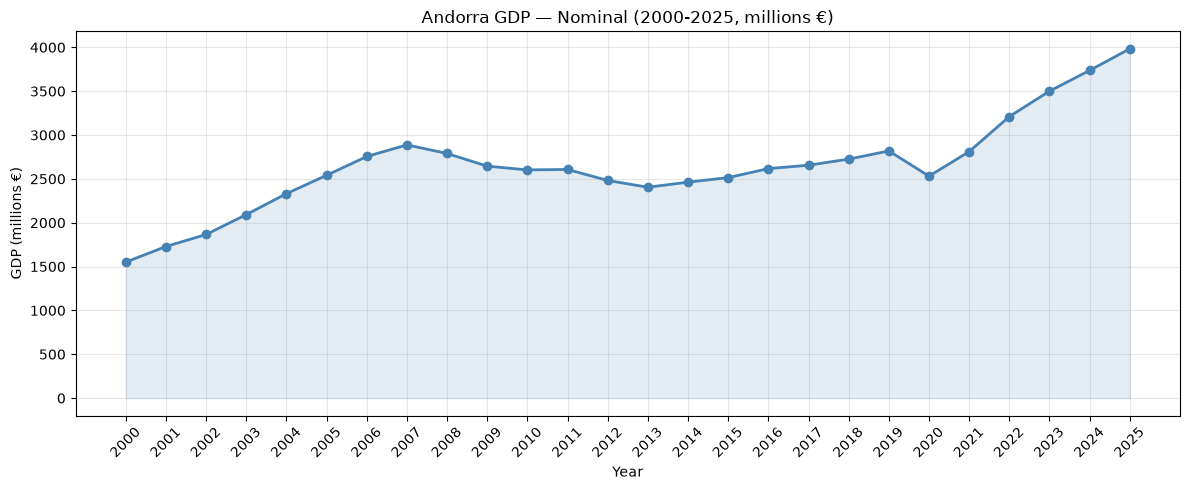

In [2]:
# Extract PIB nominal (first row) and years
years_pib = [col for col in df_pib.columns if col.isdigit()]
pib_nominal = df_pib[df_pib['Descripció'].str.contains('NOMINAL')].iloc[0][years_pib].astype(float).values

plt.figure(figsize=(12, 5))
plt.plot(years_pib, pib_nominal, marker='o', color='steelblue', linewidth=2)
plt.fill_between(years_pib, pib_nominal, alpha=0.15, color='steelblue')
plt.title("Andorra GDP — Nominal (2000-2025, millions €)")
plt.xlabel("Year")
plt.ylabel("GDP (millions €)")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/gdp_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## 1. Andorra GDP Evolution (2000-2025)

Andorra's nominal GDP grew from €1.55B in 2000 to a historic high of €3.98B in 2025.
Two major crises are clearly visible: the 2008 financial crisis (peak €2.89B in 2007, 
not recovered until 2022 — a 15-year stagnation) and the COVID-19 shock in 2020.
The post-2021 acceleration reflects strong recovery driven by tourism and commerce.

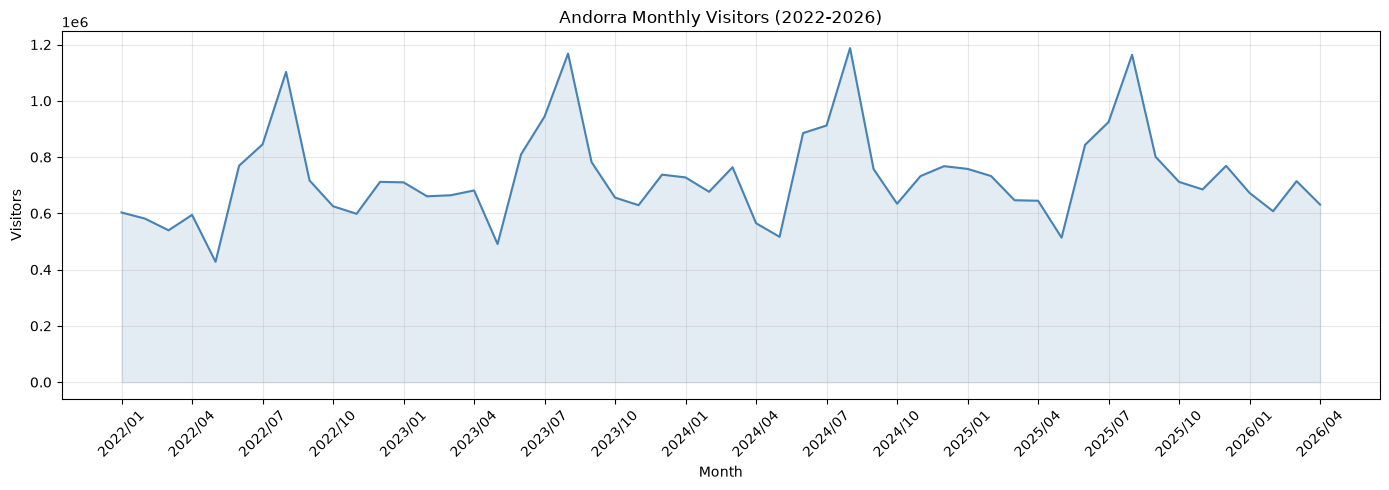

In [3]:
# Extract monthly visitor data
months = [col for col in df_visitors.columns if '/' in col]
visitors_total = df_visitors[months].iloc[0].astype(float).values

# Create month labels
month_labels = months

plt.figure(figsize=(14, 5))
plt.plot(month_labels, visitors_total, color='steelblue', linewidth=1.5)
plt.fill_between(range(len(month_labels)), visitors_total, alpha=0.15, color='steelblue')
plt.title("Andorra Monthly Visitors (2022-2026)")
plt.xlabel("Month")
plt.ylabel("Visitors")
plt.xticks(range(0, len(month_labels), 3), month_labels[::3], rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output/visitors_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Monthly Visitor Seasonality (2022-2026)

Andorra shows a clear dual-season tourism pattern: 
a primary peak in July-August (~1.1M visitors/month) driven by summer shopping and leisure,
and a secondary peak in January-February driven by ski tourism at Grandvalira.
April-May and October-November are consistent low seasons.
This pattern repeats with high regularity across all years, 
reflecting Andorra's structural dependence on seasonal tourism.

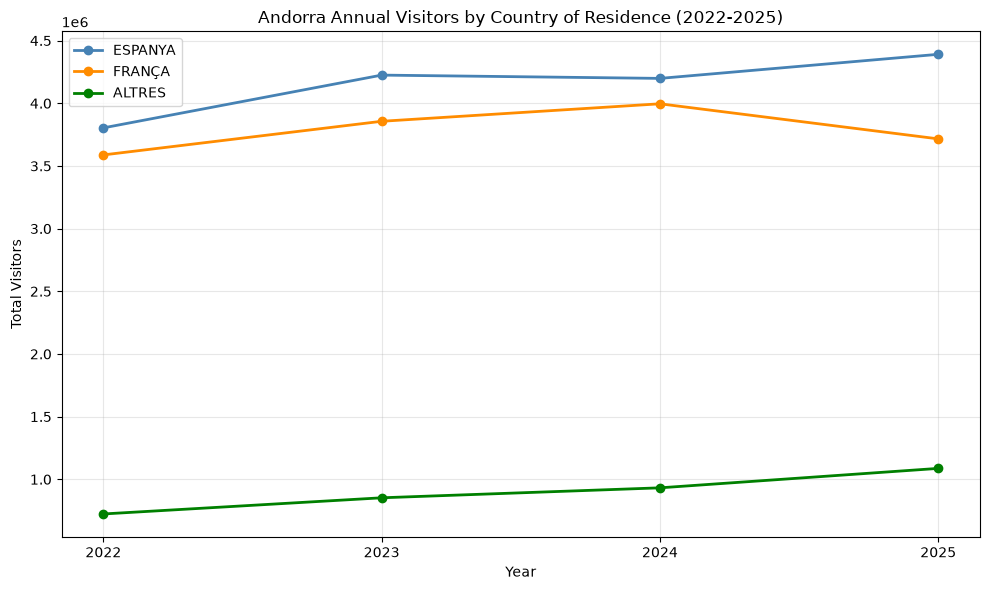

In [7]:
# Visitors by country - annual totals
months = [col for col in df_visitors_country.columns if '/' in col]

# Group by year
df_visitors_country['name'] = df_visitors_country['Descripció'].str.extract(r'\. (.+)$')

# Sum by year for each country
years_unique = sorted(set(col[:4] for col in months if not col.startswith('2026')))
country_annual = {}

for _, row in df_visitors_country.iterrows():
    country = row['name']
    annual = []
    for year in years_unique:
        year_cols = [col for col in months if col.startswith(year)]
        total = row[year_cols].astype(float).sum()
        annual.append(total)
    country_annual[country] = annual

plt.figure(figsize=(10, 6))
colors = ['steelblue', 'darkorange', 'green']
for i, (country, values) in enumerate(country_annual.items()):
    plt.plot(years_unique, values, marker='o', linewidth=2, 
             label=country, color=colors[i])

plt.title("Andorra Annual Visitors by Country of Residence (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Visitors")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output/visitors_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Annual Visitors by Country of Residence (2022-2025)

Spain and France together account for over 85% of Andorra's visitors,
reflecting the country's geographical position between both nations.
Spanish visitors (~4.4M in 2025) outnumber French visitors (~3.7M),
while the "Others" category shows steady growth — suggesting gradual 
tourism diversification beyond the two border countries.
Note: 2026 data excluded as the year is incomplete.

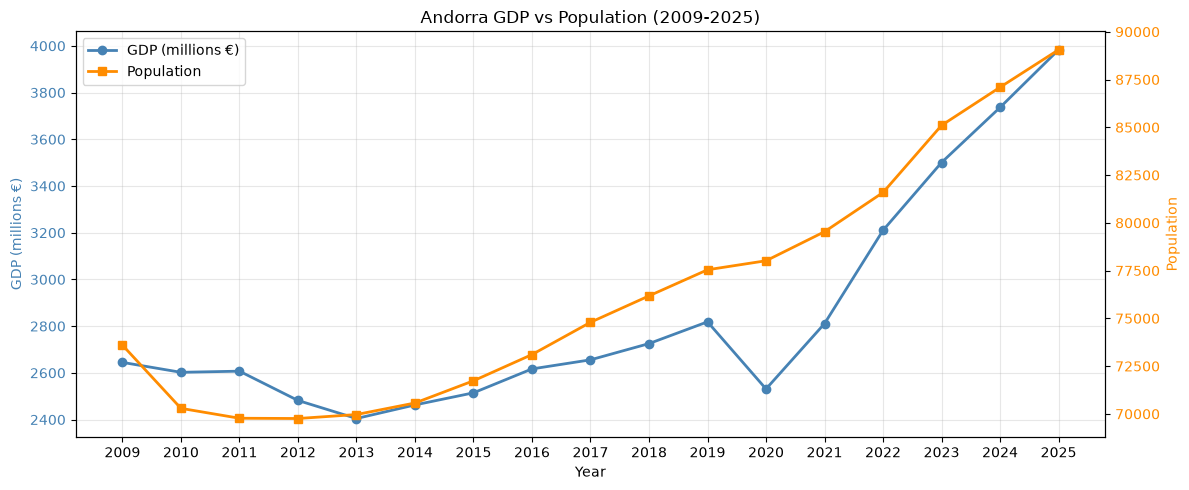

In [8]:
# PIB nominal vs population correlation
pib_years = [col for col in df_pib.columns if col.isdigit()]
pib_values = df_pib[df_pib['Descripció'].str.contains('NOMINAL')].iloc[0][pib_years].astype(float).values

# Population data (from notebook 1 — manual from what we already know)
pop_years = ['2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']
pop_values = [73600,70290,69772,69758,69966,70570,71732,73105,74794,76177,77543,78015,79535,81588,85101,87097,89058]

# Filter PIB to matching years
pib_filtered = df_pib[df_pib['Descripció'].str.contains('NOMINAL')].iloc[0][pop_years].astype(float).values

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(pop_years, pib_filtered, color='steelblue', marker='o', linewidth=2, label='GDP (millions €)')
ax1.set_ylabel('GDP (millions €)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(pop_years, pop_values, color='darkorange', marker='s', linewidth=2, label='Population')
ax2.set_ylabel('Population', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title("Andorra GDP vs Population (2009-2025)")
ax1.set_xlabel("Year")
ax1.grid(alpha=0.3)
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("output/gdp_vs_population.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. GDP vs Population (2009-2025)

GDP and population show strong long-term correlation, but with notable divergences.
During the 2009-2013 crisis, both fell together as emigrants left Andorra.
Between 2013-2019, population recovered faster than GDP — suggesting people 
returned before the economy fully rebounded.
COVID-19 (2020) caused a sharp GDP drop with minimal population impact,
indicating residents chose to stay despite the economic shock.
Post-2021, both indicators accelerate together, reflecting synchronized growth.

## Conclusions

This economic analysis of Andorra (2000-2025) reveals four key findings:

1. **GDP grew 157% in 25 years** — from €1.55B (2000) to €3.98B (2025), 
   reaching a historic high. However, the 2008 financial crisis caused 
   a 15-year stagnation — the pre-crisis peak of 2007 was not recovered until 2022.

2. **Andorra has a dual-season tourism economy** — July-August (summer shopping) 
   and January-February (ski season at Grandvalira) generate the highest visitor 
   peaks (~1.1M/month). April-May and October-November are structural low seasons.

3. **Spain and France account for 85%+ of visitors** — a direct consequence 
   of Andorra's geographical position. "Others" growing steadily suggests 
   slow but real tourism diversification.

4. **GDP and population are correlated but not perfectly synchronized** — 
   population reacts more slowly to economic shocks. During COVID-19, 
   GDP dropped sharply while population remained stable, suggesting 
   residents' confidence in Andorra's long-term prospects.

*Data source: Departament d'Estadística d'Andorra (estadistica.ad)*